# Signed Friedkin-Johnsen Model on Toy Cases

This notebook applies the same Signed Friedkin-Johnsen model and the same helper functions from `SFJModel.ipynb` to the eight networks specified in `ToyCases.txt`.

For every case, the notebook builds `W` with `build_W_from_edges`, checks the assumptions and spectral stability, simulates the SFJ dynamics with `simulate_sfj`, computes the equilibrium with `compute_sfj_equilibrium`, reports the existing metrics, and uses the same plotting functions as the source model.

The convention is unchanged: `W[i, j]` is the influence of agent `j` on agent `i`, so each tuple `(i, j, weight)` means that agent `j` influences agent `i` with the given signed weight.


## Model Functions Copied from `SFJModel.ipynb`

The following cells preserve the imports and SFJ functions used by the original model.


### 1. Import libraries


In [1]:

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Circle
import warnings

plt.rcParams.update({"figure.figsize": (7.5, 5.0), "font.size": 11, "axes.grid": True, "axes.spines.top": False, "axes.spines.right": False,})

np.set_printoptions(precision=4, suppress=True)


### 2. Input validation functions


In [2]:
#verifica che M sia una matrice quadrata 
def as_square_matrix(M, name="matrix"):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError(f"{name} must be a square matrix.")
    return M

# verifica che v sia un vettore colonna di dimensione n
def as_vector(v, n, name="vector"):
    v = np.asarray(v, dtype=float).reshape(-1)
    if v.size != n:
        raise ValueError(f"{name} must have length {n}.")
    return v


### 3. Building W function
build signed influence matrices W 
costruisce W da una lista di tuple (influenced_i, influencer_j, weight), dove i e j sono gli agenti coinvolti e weight è il peso dell'influenza
Example: (3, 1, -0.4) means W[2, 0] = -0.4, i.e. agent 1 antagonistically influences agent 3.


In [3]:
def build_W_from_edges(edges, n=6):
    W = np.zeros((n, n))
    for i, j, weight in edges:
        W[i - 1, j - 1] = weight

    #choose the diagonal so each row sums to one.
    for i in range(n):
        W[i, i] = 1.0 - np.sum(W[i, :])
    return W


### 4. SFJ Simulation 
simula la dinamica di SFJ per T iterazioni, partendo da x0 e usando W e theta


In [4]:
def simulate_sfj(W, theta, s, T):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    s = as_vector(s, n, "s")

    Theta = np.diag(theta)
    I = np.eye(n)

    A = (I - Theta) @ W
    b = Theta @ s

    X = np.zeros((n, T + 1))
    X[:, 0] = s

    for t in range(T):
        X[:, t + 1] = A @ X[:, t] + b

    return X


calcola l'equilibrio di SFJ, cioè P_W e x_star, se l'inversa esiste. P_W è la matrice che mappa x0 a x_star, e x_star è l'equilibrio raggiunto partendo da x0.


In [5]:
def compute_sfj_equilibrium(W, theta, s):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    s = as_vector(s, n, "s")

    Theta = np.diag(theta)
    I = np.eye(n)

    A = (I - Theta) @ W
    P_W = np.linalg.inv(I - A) @ Theta
    x_star = P_W @ s

    return P_W, x_star


### 5. Math diagnosis 
calcola un approssimazione del numerical range boundary


In [6]:
def numerical_range_boundary(Q, Ntheta=800):
    """Approximate the boundary of the numerical range omega(Q)."""
    Q = as_square_matrix(Q, "Q")
    angles = np.linspace(0, 2 * np.pi, int(Ntheta), endpoint=False)
    boundary = np.zeros(len(angles), dtype=complex)

    for idx, phi in enumerate(angles):
        rotated = np.exp(1j * phi) * Q
        H = (rotated + rotated.conj().T) / 2
        eigvals, eigvecs = la.eigh(H)
        v = eigvecs[:, np.argmax(eigvals)]
        boundary[idx] = np.vdot(v, Q @ v)

    return boundary


warnings about potential issues with the assumptions on theta and W, to avoid misinterpreting a simulation that violates some of the main assumptions of the paper.


In [7]:
def warn_about_assumptions(W, theta):
    """Collect the main caveats before interpreting a simulation."""
    W = as_square_matrix(W, "W")
    theta = as_vector(theta, W.shape[0], "theta")

    if np.any(theta < 0) or np.any(theta > 1):
        warnings.warn("Some theta_i are outside [0, 1]. The standard SFJ interpretation may fail.")

    if np.any(np.isclose(theta, 1.0)):
        warnings.warn(
            "Fully stubborn agents with theta_i = 1 are excluded by the main assumptions of the paper. "
            "Simulation is possible, but the theoretical guarantees used here do not apply."
        )

    if np.any(np.isclose(theta, 0.0)):
        warnings.warn(
            "Some agents have theta_i = 0. Fully non-stubborn agents require care when checking "
            "some reduced-form theoretical conditions."
        )

    row_sums = W.sum(axis=1)
    if not np.allclose(row_sums, np.ones(W.shape[0]), atol=1e-10):
        warnings.warn("Rows of W do not sum to one, so W @ 1 = 1 is not satisfied numerically.")


Check spectral properties related to stability and existence of P_W, and print them in a readable format


In [8]:
def check_sfj_stability(W, theta):
    """Print the spectral quantities I usually inspect first."""
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    theta = as_vector(theta, n, "theta")
    Theta = np.diag(theta)
    A = (np.eye(n) - Theta) @ W

    eig_W = la.eigvals(W)
    eig_A = la.eigvals(A)
    rho_W = np.max(np.abs(eig_W))
    rho_A = np.max(np.abs(eig_A))

    print("Basic checks")
    print("------------")
    print("row sums of W:", W.sum(axis=1))
    print("W @ 1 = 1:", np.allclose(W.sum(axis=1), np.ones(n), atol=1e-10))
    print()

    print("Spectrum")
    print("--------")
    print("eig(W):", eig_W)
    print(f"rho(W) = {rho_W:.6f}")
    print("eig((I-Theta)W):", eig_A)
    print(f"rho((I-Theta)W) = {rho_A:.6f}")
    print("stable by the numerical test rho((I-Theta)W) < 1:", rho_A < 1)
    print()

    P_W, _ = compute_sfj_equilibrium(W, theta, np.zeros(n))
    if P_W is None:
        print("P_W exists numerically: False")
        print("Eigenvalues of P_W: not computable")
        print("rho(P_W): not computable")
    else:
        eig_P = la.eigvals(P_W)
        print("P_W exists numerically: True")
        print("eig(P_W):", eig_P)
        print(f"rho(P_W) = {np.max(np.abs(eig_P)):.6f}")

    print()
    print("ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.")


### 6. Metrics
opinion-level Metrics 
At the opinion level, we track the average opinion, the variance of opinions as a polarization measure, and the average absolute opinion as an extremism measure. At the stability level, we compute the spectral radius of the dynamic matrix (I - Θ)W, the corresponding stability margin, a simple convergence-time proxy, and the fraction of negative edges in the signed network.


In [9]:
# media delle opinioni
def mean_opinion(x):
    """Return the average opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    return float(np.mean(x))

#polarizzazione: varianza media delle opinioni rispetto alla media
def polarization_variance(x):
    """Return the mean squared deviation from the average opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    mu = np.mean(x)
    return float(np.mean((x - mu) ** 2))

#estremismo: media degli assoluti delle opinioni
def mean_extremism(x):
    """Return the average absolute opinion."""
    x = np.asarray(x, dtype=float).reshape(-1)
    return float(np.mean(np.abs(x)))


def compute_opinion_metrics(x):
    """Return the three opinion-level metrics for one opinion vector."""
    return {
        "mean_opinion": mean_opinion(x),
        "polarization_variance": polarization_variance(x),
        "mean_extremism": mean_extremism(x),
    }


def compute_opinion_metrics_trajectory(X):
    """Return opinion-level metrics over a trajectory with shape (T+1, n)."""
    X = np.asarray(X, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array with shape (T+1, n).")

    means = np.mean(X, axis=1)
    return {
        "mean_opinion": means,
        "polarization_variance": np.mean((X - means[:, None]) ** 2, axis=1),
        "mean_extremism": np.mean(np.abs(X), axis=1),
    }


stability-level metrics


In [10]:
#calcolo della matrice dinamica (I - Theta)W che è alla base di tutte le metriche di stabilità 
def sfj_dynamic_matrix(W, theta):
    W = np.asarray(W, dtype=float)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("W must be a square matrix.")

    theta = np.asarray(theta, dtype=float).reshape(-1)
    if theta.size != W.shape[0]:
        raise ValueError(f"theta must have length {W.shape[0]}.")

    Theta = np.diag(theta)
    return (np.eye(W.shape[0]) - Theta) @ W

#calcolo del raggio spettrale di una matrice quadrata rho < 1   → dinamica stabile/convergente, rho ≈ 1   → convergenza lenta o comportamento al limite,rho > 1   → possibile instabilità/divergenza
def spectral_radius(M):
    M = np.asarray(M, dtype=float)
    if M.ndim != 2 or M.shape[0] != M.shape[1]:
        raise ValueError("M must be a square matrix.")
    if M.shape[0] == 0:
        return 0.0
    return float(np.max(np.abs(np.linalg.eigvals(M))))

#calcolo del raggio spettrale di (I - Theta)W che è alla base della stabilità del modello SFJ
def sfj_spectral_radius(W, theta):
    return spectral_radius(sfj_dynamic_matrix(W, theta))

#stability margin: 1 minus the spectral radius of (I - Theta)W, misura di vicinanza all'instabilità, più è grande più siamo lontani da rho = 1, più è piccolo più siamo vicini a rho = 1
#m_rho > 0   → stabile
#m_rho = 0   → al limite
#m_rho < 0   → instabile
def stability_margin(W, theta):
    return 1.0 - sfj_spectral_radius(W, theta)

#proxy della velocità di convergenza: rho = 0.5   → convergenza veloce, rho = 0.9   → convergenza lenta, rho = 0.99  → convergenza molto lenta
#Return 1 / (1 - rho) if rho < 1, otherwise infinity. This is a common proxy for convergence time in linear systems, as the error typically decreases by a factor of rho each iteration
def convergence_time_proxy(W, theta):
    rho = sfj_spectral_radius(W, theta)
    if rho < 1:
        return 1.0 / (1.0 - rho)
    return np.inf

#misura quanto antagonistica è la rete, più è alta più la rete ha molti legami negativi rispetto a quelli totali, più è bassa più la rete ha pochi legami negativi rispetto a quelli totali
#Return the fraction of nonzero edges with negative weight.
def negative_edge_fraction(W):
    W = np.asarray(W, dtype=float)
    nonzero_edges = W != 0
    edge_count = np.count_nonzero(nonzero_edges)
    if edge_count == 0:
        return 0.0
    return float(np.count_nonzero(W < 0) / edge_count)


def compute_stability_metrics(W, theta):
    """Return the four stability-level metrics for the SFJ model."""
    rho = sfj_spectral_radius(W, theta)
    return {
        "spectral_radius": rho,
        "stability_margin": 1.0 - rho,
        "convergence_time_proxy": 1.0 / (1.0 - rho) if rho < 1 else np.inf,
        "negative_edge_fraction": negative_edge_fraction(W),
    }


### 6. Plotting functions


In [11]:
#plotta gli autovalori di W nel piano complesso, con il cerchio unitario e gli assi cartesiani per riferimento
def plot_eigenvalues(W):
    W = as_square_matrix(W, "W")
    eig_W = la.eigvals(W)

    fig, ax = plt.subplots()
    ax.add_patch(Circle((0, 0), 1, fill=False, linestyle="--", color="black", linewidth=1.2))
    ax.scatter(eig_W.real, eig_W.imag, color="red", s=55, label="eigenvalues of W", zorder=3)
    ax.axhline(0, color="0.4", linewidth=0.8)
    ax.axvline(0, color="0.4", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Eigenvalues of W")
    ax.set_xlabel("Real part")
    ax.set_ylabel("Imaginary part")
    ax.legend()
    lim = max(1.2, np.max(np.abs(np.r_[eig_W.real, eig_W.imag])) + 0.2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    plt.show()

#plotta la rete diretta con archi rosse per influenze positive e blu per influenze negative, usando xpos e ypos per le posizioni dei nodi
def plot_signed_network(W, xpos, ypos):
    W = as_square_matrix(W, "W")
    n = W.shape[0]
    pos = {i: (xpos[i], ypos[i]) for i in range(n)}

    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    positive_edges = []
    negative_edges = []

    for i in range(n):
        for j in range(n):
            if i == j or np.isclose(W[i, j], 0):
                continue
            G.add_edge(j, i)
            if W[i, j] > 0:
                positive_edges.append((j, i))
            else:
                negative_edges.append((j, i))

    fig, ax = plt.subplots()
    nx.draw_networkx_nodes(G, pos, node_color="black", node_size=520, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={i: str(i + 1) for i in range(n)}, font_color="white", ax=ax)
    nx.draw_networkx_edges(
        G, pos, edgelist=positive_edges, edge_color="red", arrows=True,
        arrowsize=18, width=[1 + 2 * abs(W[v, u]) for u, v in positive_edges],
        connectionstyle="arc3,rad=0.10", ax=ax,
    )
    nx.draw_networkx_edges(
        G, pos, edgelist=negative_edges, edge_color="blue", arrows=True,
        arrowsize=18, width=[1 + 2 * abs(W[v, u]) for u, v in negative_edges],
        connectionstyle="arc3,rad=-0.10", ax=ax,
    )
    ax.set_title("Signed Directed Network")
    ax.set_axis_off()
    plt.show()

#plotta la matrice W come una heatmap, con colori blu per valori negativi e rossi per valori positivi, e una barra colore che mostra la scala dei valori.
def plot_heatmap_W(W):
    W = as_square_matrix(W, "W")
    max_abs = max(1e-12, np.max(np.abs(W)))

    fig, ax = plt.subplots()
    im = ax.imshow(W, cmap="bwr", vmin=-max_abs, vmax=max_abs)
    ax.set_title("Signed Influence Matrix W")
    ax.set_xlabel("Influencing agent j")
    ax.set_ylabel("Influenced agent i")
    ax.set_xticks(range(W.shape[1]), labels=np.arange(1, W.shape[1] + 1))
    ax.set_yticks(range(W.shape[0]), labels=np.arange(1, W.shape[0] + 1))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

#plotta le traiettorie delle opinioni di tutti gli agenti nel tempo, usando marker per evidenziare i punti discreti, e una legenda che identifica ogni agente
def plot_opinion_trajectories(X, title):
    X = np.asarray(X, dtype=float)
    k_values = np.arange(X.shape[1])

    fig, ax = plt.subplots()
    for i in range(X.shape[0]):
        ax.plot(k_values, X[i, :], marker="o", markersize=3, linewidth=1.8, label=f"Agent {i + 1}")
    ax.set_title(title)
    ax.set_xlabel("Time step k")
    ax.set_ylabel("Opinion")
    ax.legend(ncol=2)
    plt.show()


#plotta il numerical range di W, con il cerchio unitario e gli autovalori di W evidenziati, per mostrare la posizione degli autovalori rispetto al numerical range e al cerchio unitario
def plot_numerical_range(W):
    W = as_square_matrix(W, "W")
    boundary = numerical_range_boundary(W)
    eig_W = la.eigvals(W)
    unit_circle = np.exp(1j * np.linspace(0, 2 * np.pi, 500))

    fig, ax = plt.subplots()
    ax.fill(boundary.real, boundary.imag, color="lightsteelblue", alpha=0.65, label="numerical range")
    ax.plot(boundary.real, boundary.imag, color="royalblue", linewidth=1.4)
    ax.plot(unit_circle.real, unit_circle.imag, "k--", linewidth=1.1, label="unit circle")
    ax.scatter(eig_W.real, eig_W.imag, color="red", s=45, label="eigenvalues", zorder=3)
    ax.axhline(0, color="0.4", linewidth=0.8)
    ax.axvline(0, color="0.4", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title("Numerical Range of W")
    ax.set_xlabel("Real part")
    ax.set_ylabel("Imaginary part")
    ax.legend()
    plt.show()


## Common Simulation Settings

All toy cases use the same six-node layout, the same initial opinion vector, and the same horizon. Only the edge weights and stubbornness vector change across cases, exactly as specified in `ToyCases.txt`.


In [22]:

#define the position of the nodes in the network
xpos = np.array([4.2, 2.7, 1.6, 2.5, 0.5, 5.8])
ypos = np.array([4.3, 4.3, 2.8, 1.5, 1.5, 2.8])

#initial opinions of the agents, kept equal to SFJModel.ipynb
s = np.array([-0.30, -0.20, -0.55, 0.5, 0.2, 0.55])
T = 30

case_results = {}


## Case 1 - Rete positiva cooperativa

Tutti i pesi sono positivi, è il caso base del FJ.

Serve per mostrare il caso più semplice: la rete tende a un compromesso/consenso influenzato dalle stubbornness.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.    +0.j  0.9417+0.j  0.2478+0.j  0.1045+0.j -0.0175+0.j  0.0235+0.j]
rho(W) = 1.000000
eig((I-Theta)W): [ 0.6271+0.j  0.5881+0.j  0.1629+0.j  0.0606+0.j  0.0147+0.j -0.0108+0.j]
rho((I-Theta)W) = 0.627074
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [1.    +0.j 0.914 +0.j 0.4634+0.j 0.3343+0.j 0.3692+0.j 0.4057+0.j]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[0.45 0.35 0.2  0.   0.   0.  ]
 [0.35 0.35 0.3  0.   0.   0.  ]
 [0.2  0.3  0.4  0.1  0.   0.  ]
 [0.   0.   0.1  0.35 0.3  0.25]
 [0.   0.   0.   0.35 0.35 0.3 ]
 [0.   0.   0.   0.25 0.35 0.4 ]]

Stubbornness vector theta:
[0.3  0.45 0.35 0.4  0.3  0.45]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-0.2912 -0.2509 -0.3429  0.3933  0.33

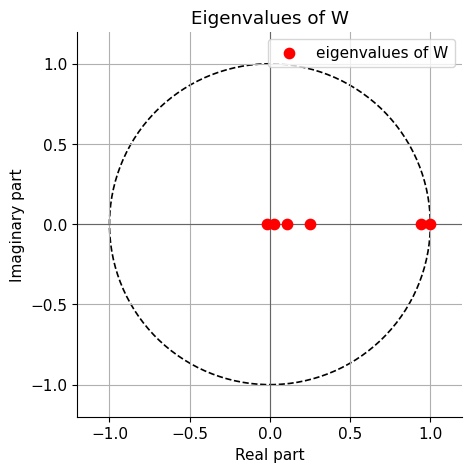

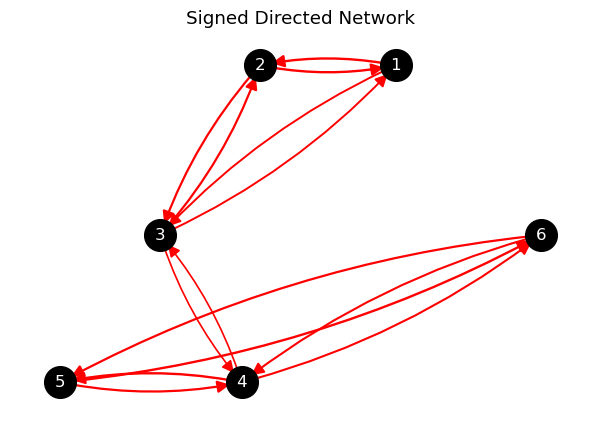

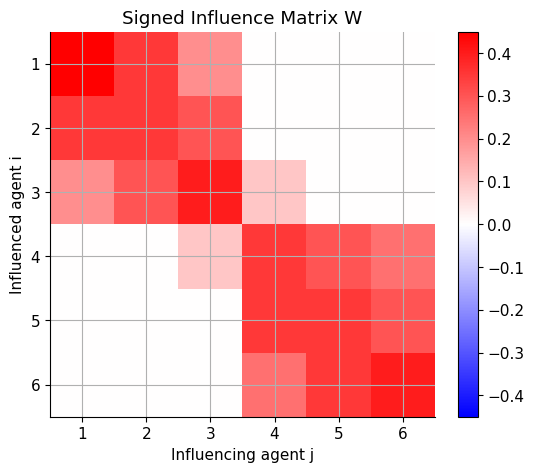

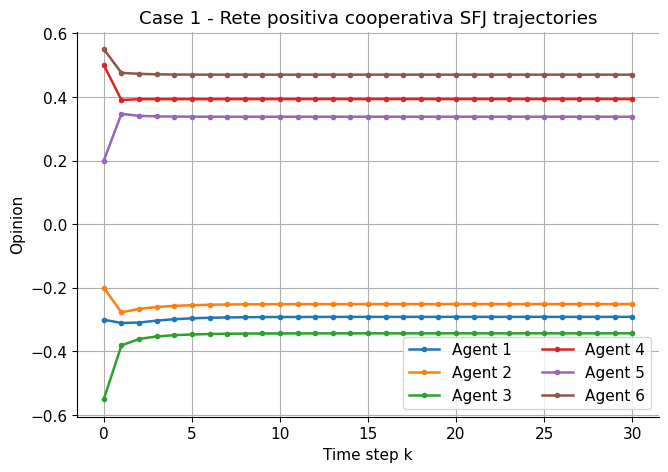

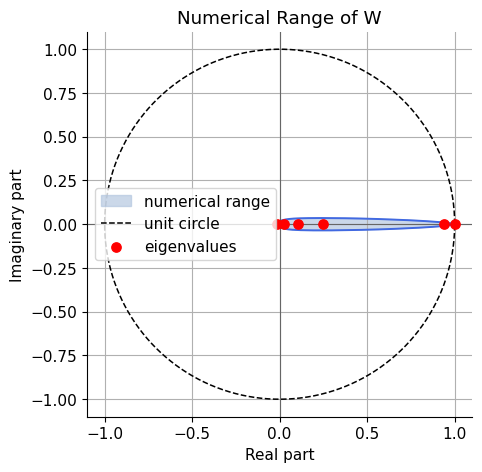

In [23]:

# Case 1 - Rete positiva cooperativa
a12 = 0.35
a13 = 0.20
a21 = 0.35
a23 = 0.30
a31 = 0.20
a32 = 0.30
a34 = 0.10
a43 = 0.10
a45 = 0.30
a46 = 0.25
a54 = 0.35
a56 = 0.30
a64 = 0.25
a65 = 0.35

edges = [
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),
    (3, 4, a34),
    (4, 3, a43),
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),
]

theta = np.array([0.30, 0.45, 0.35, 0.40, 0.30, 0.45])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[1] = {
    "name": "Case 1 - Rete positiva cooperativa",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 1 - Rete positiva cooperativa SFJ trajectories")
plot_numerical_range(W)


## Case 2 - Due cluster positivi debolmente connessi

Due gruppi interni molto coesi, con pochi archi deboli tra loro.

Esempio: nodi 1–3 negativi, nodi 4–6 positivi.

Questo caso serve per vedere se il modello tende a:

consenso globale;
polarizzazione moderata;
persistenza di due blocchi.

nota: stubborness non cambia rispetto al caso 1.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.    +0.j  0.9687+0.j  0.006 +0.j -0.234 +0.j -0.113 +0.j -0.1776+0.j]
rho(W) = 1.000000
eig((I-Theta)W): [ 0.6271+0.j  0.6036+0.j  0.0039+0.j -0.0655+0.j -0.1414+0.j -0.1151+0.j]
rho((I-Theta)W) = 0.627063
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [1.    +0.j 0.9516+0.j 0.3025+0.j 0.2996+0.j 0.3708+0.j 0.3996+0.j]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[0.25 0.45 0.3  0.   0.   0.  ]
 [0.45 0.2  0.35 0.   0.   0.  ]
 [0.3  0.35 0.3  0.05 0.   0.  ]
 [0.   0.   0.05 0.2  0.4  0.35]
 [0.   0.   0.   0.4  0.25 0.35]
 [0.   0.   0.   0.35 0.4  0.25]]

Stubbornness vector theta:
[0.3  0.45 0.35 0.4  0.3  0.45]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-0.3052 -0.2663 -0.3712  0.425   0.35

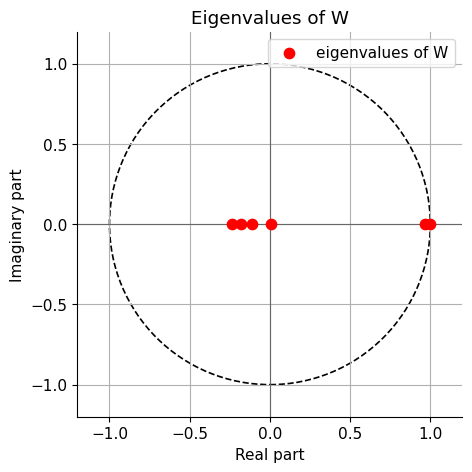

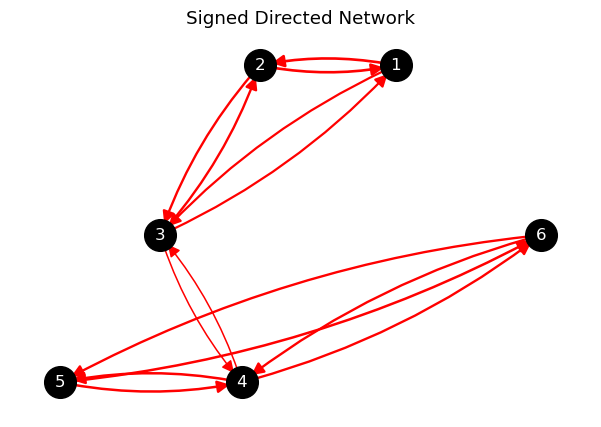

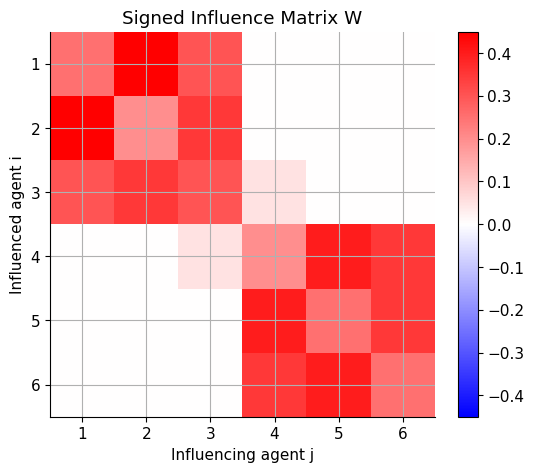

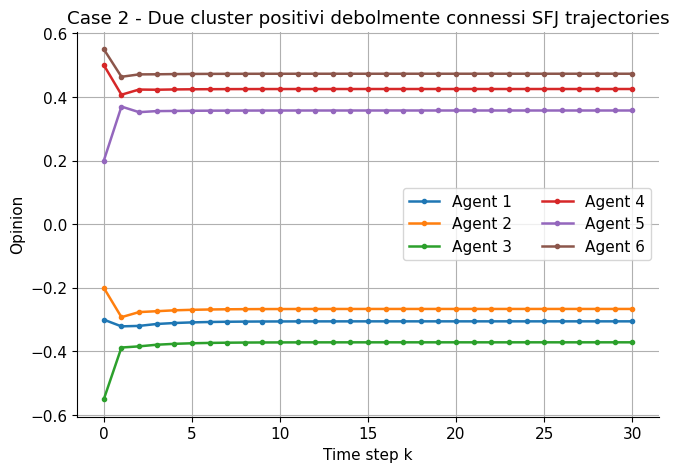

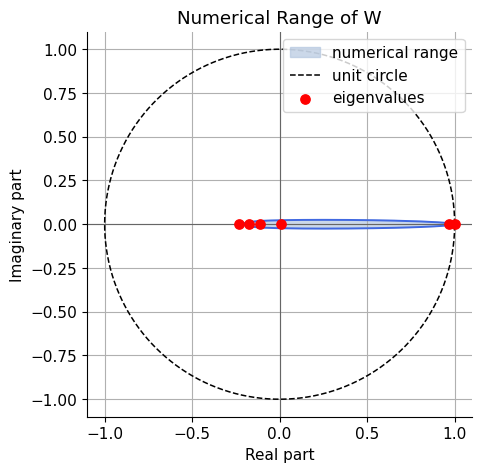

In [24]:

# Case 2 - Due cluster positivi debolmente connessi
a12 = 0.45
a13 = 0.30
a21 = 0.45
a23 = 0.35
a31 = 0.30
a32 = 0.35

a45 = 0.40
a46 = 0.35
a54 = 0.40
a56 = 0.35
a64 = 0.35
a65 = 0.40

# weak positive bridge between clusters
a34 = 0.05
a43 = 0.05

edges = [
    # cluster 1
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),

    # weak bridge
    (3, 4, a34),
    (4, 3, a43),

    # cluster 2
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),
]

theta = np.array([0.30, 0.45, 0.35, 0.40, 0.30, 0.45])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[2] = {
    "name": "Case 2 - Due cluster positivi debolmente connessi",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 2 - Due cluster positivi debolmente connessi SFJ trajectories")
plot_numerical_range(W)


## Case 3 - Rete signed con antagonismo tra due gruppi

Dentro ogni gruppo hai archi positivi, tra gruppi hai archi negativi.

Questa è la prima rete davvero interessante per SFJ, perché puoi mostrare che il segno degli archi cambia qualitativamente la dinamica.

In questo caso puoi cercare:

polarizzazione stabile;
consenso bipolare;
amplificazione delle opinioni estreme;
dipendenza forte dalle condizioni iniziali e dalla stubbornness.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.24  +0.j  1.    +0.j  0.2238+0.j -0.1988+0.j  0.0528+0.j -0.0479+0.j]
rho(W) = 1.240000
eig((I-Theta)W): [ 0.7758+0.j  0.625 +0.j  0.142 +0.j -0.1238+0.j  0.033 +0.j -0.0294+0.j]
rho((I-Theta)W) = 0.775759
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [1.6666+0.j 1.    +0.j 0.433 +0.j 0.3324+0.j 0.3623+0.j 0.3911+0.j]
rho(P_W) = 1.666560

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[ 0.37  0.45  0.3  -0.12  0.    0.  ]
 [ 0.45  0.32  0.35  0.   -0.12  0.  ]
 [ 0.3   0.35  0.47  0.    0.   -0.12]
 [-0.12  0.    0.    0.37  0.4   0.35]
 [ 0.   -0.12  0.    0.4   0.37  0.35]
 [ 0.    0.   -0.12  0.35  0.4   0.37]]

Stubbornness vector theta:
[0.35 0.4  0.35 0.4  0.35 0.4 ]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-

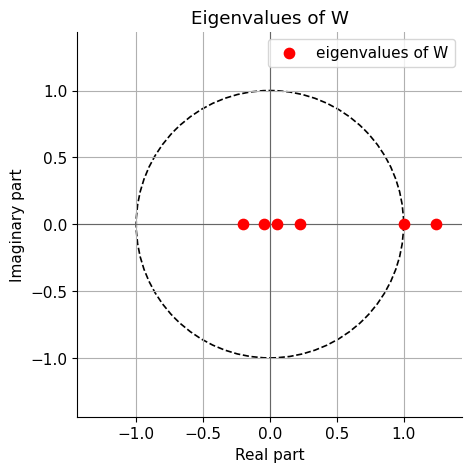

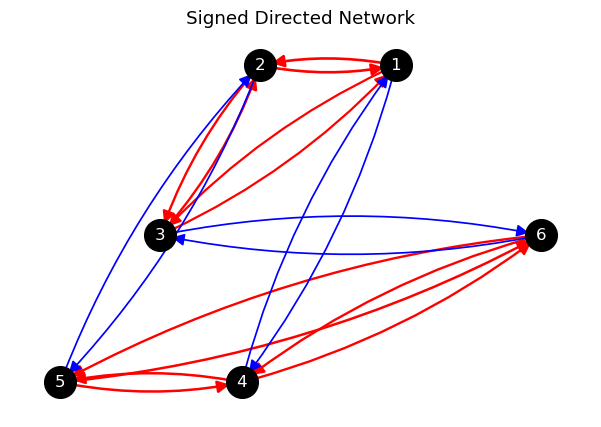

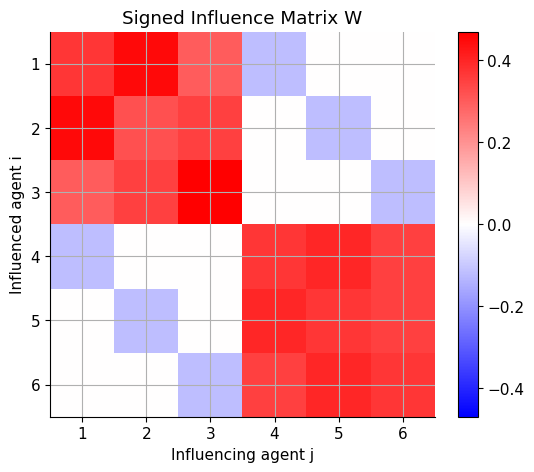

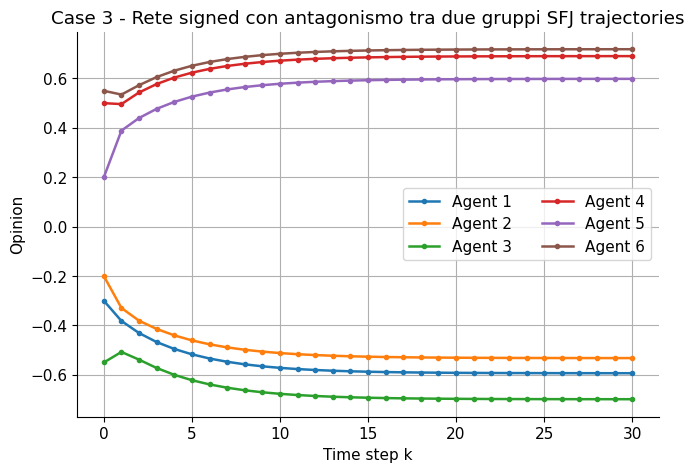

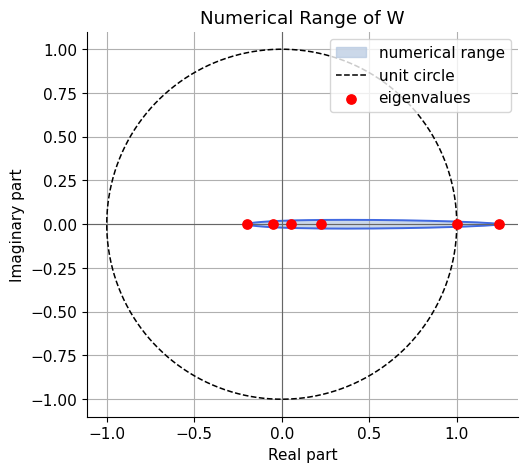

In [25]:

# Case 3 - Rete signed con antagonismo tra due gruppi
a12 = 0.45
a13 = 0.30
a21 = 0.45
a23 = 0.35
a31 = 0.30
a32 = 0.35

a45 = 0.40
a46 = 0.35
a54 = 0.40
a56 = 0.35
a64 = 0.35
a65 = 0.40

# weak negative cross-cluster antagonism
a14 = -0.12
a25 = -0.12
a36 = -0.12
a41 = -0.12
a52 = -0.12
a63 = -0.12

edges = [
    # positive cluster 1
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),

    # positive cluster 2
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),

    # negative antagonistic relations between clusters
    (1, 4, a14),
    (2, 5, a25),
    (3, 6, a36),
    (4, 1, a41),
    (5, 2, a52),
    (6, 3, a63),
]

theta = np.array([0.35, 0.40, 0.35, 0.40, 0.35, 0.40])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[3] = {
    "name": "Case 3 - Rete signed con antagonismo tra due gruppi",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 3 - Rete signed con antagonismo tra due gruppi SFJ trajectories")
plot_numerical_range(W)


## Case 4 - Nodo altamente stubborn

Prendi una rete piccola e metti un nodo con:

θ≈1

Questo nodo diventa una specie di “anchor” dell’opinione. Serve per mostrare come un singolo nodo molto stubborn possa trascinare o bloccare il consenso.

Qui puoi confrontare due simulazioni identiche:

tutti i nodi moderatamente stubborn;
un nodo quasi completamente stubborn.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [1.    +0.j 0.8583+0.j 0.1104+0.j 0.2385+0.j 0.5055+0.j 0.4373+0.j]
rho(W) = 1.000000
eig((I-Theta)W): [0.3129+0.j 0.2482+0.j 0.1747+0.j 0.0833+0.j 0.0411+0.j 0.0113+0.j]
rho((I-Theta)W) = 0.312875
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [0.6774+0.j 0.7091+0.j 0.7875+0.j 0.8592+0.j 0.9442+0.j 1.    +0.j]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[0.6  0.25 0.15 0.   0.   0.  ]
 [0.25 0.45 0.2  0.   0.   0.1 ]
 [0.   0.2  0.55 0.15 0.   0.1 ]
 [0.   0.   0.15 0.35 0.25 0.25]
 [0.   0.   0.   0.25 0.5  0.25]
 [0.   0.   0.   0.15 0.15 0.7 ]]

Stubbornness vector theta:
[0.65 0.65 0.65 0.65 0.65 0.98]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-0.2957 -0.1961 -0.4082  0.4267  0.261   0.5487]


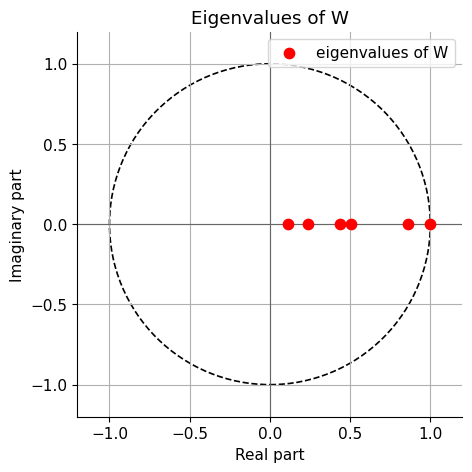

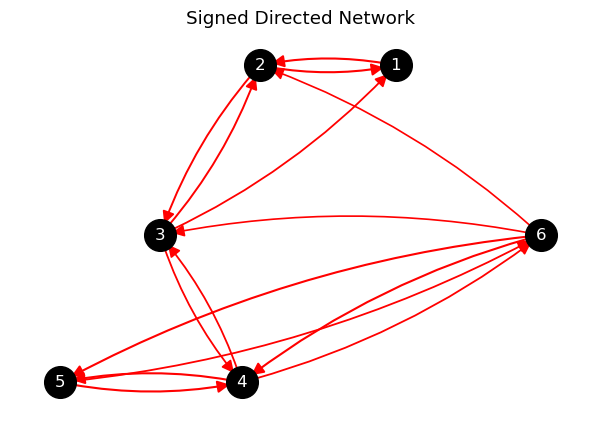

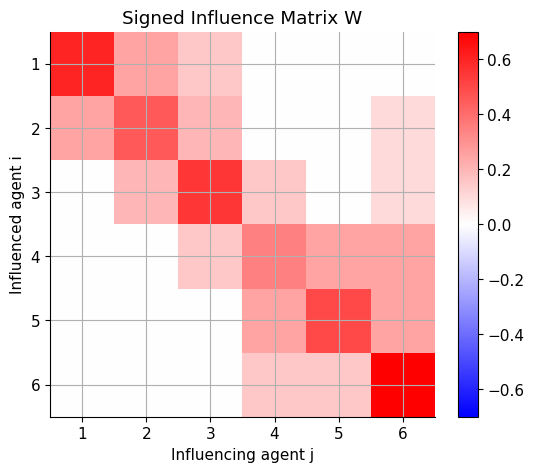

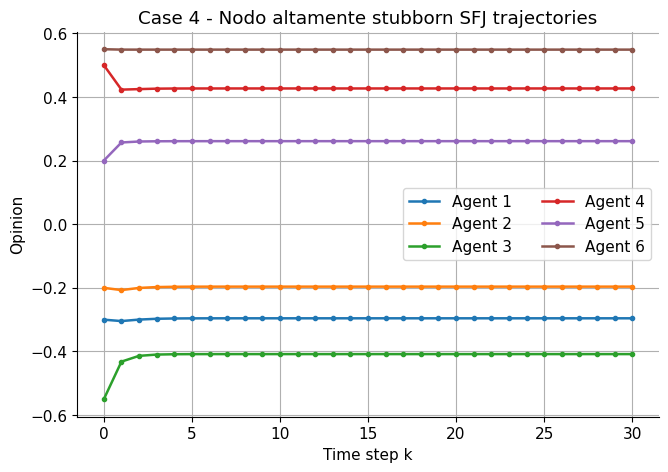

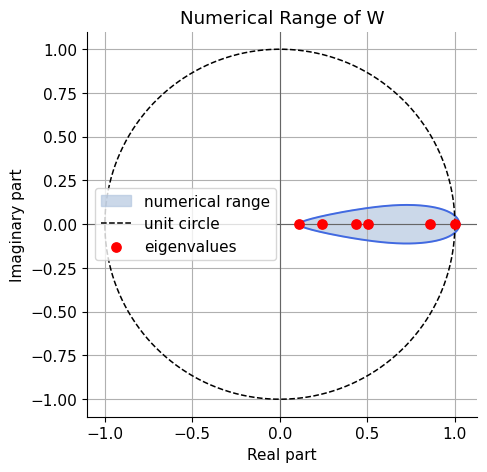

In [26]:

# Case 4 - Nodo altamente stubborn
a12 = 0.25
a13 = 0.15
a21 = 0.25
a23 = 0.20
a32 = 0.20
a34 = 0.15
a43 = 0.15
a45 = 0.25
a46 = 0.25
a54 = 0.25
a56 = 0.25
a64 = 0.15
a65 = 0.15

# node 6 also influences nodes 2 and 3
a26 = 0.10
a36 = 0.10

edges = [
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 2, a32),
    (3, 4, a34),
    (4, 3, a43),
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),

    # additional influence from node 6
    (2, 6, a26),
    (3, 6, a36),
]

# node 6 is highly stubborn
theta = np.array([0.65, 0.65, 0.65, 0.65, 0.65, 0.98])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[4] = {
    "name": "Case 4 - Nodo altamente stubborn",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 4 - Nodo altamente stubborn SFJ trajectories")
plot_numerical_range(W)


## Case 5 - Nodo molto connesso ma non stubborn

Qui fai l’opposto: un nodo è molto connesso nella rete e con influenza alta, ma bassa stubbornness. questo porta la sua opinione a cambiare parecchio. 

Questa rete è utile perché distingue due concetti diversi:

influenza strutturale: quanto un nodo pesa sugli altri tramite W;
stubbornness: quanto un nodo resta vicino alla propria opinione iniziale.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.  +0.j -0.15+0.j  0.45+0.j  0.35+0.j  0.25+0.j  0.25+0.j]
rho(W) = 1.000000
eig((I-Theta)W): [ 0.5665+0.j -0.0715+0.j  0.135 +0.j  0.075 +0.j  0.075 +0.j  0.105 +0.j]
rho((I-Theta)W) = 0.566493
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [0.1507+0.j 1.    +0.j 0.7568+0.j 0.8092+0.j 0.7821+0.j 0.7568+0.j]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[0.35 0.1  0.55 0.   0.   0.  ]
 [0.1  0.35 0.55 0.   0.   0.  ]
 [0.15 0.15 0.4  0.15 0.   0.15]
 [0.   0.   0.55 0.35 0.1  0.  ]
 [0.   0.   0.55 0.1  0.35 0.  ]
 [0.   0.   0.55 0.1  0.   0.35]]

Stubbornness vector theta:
[0.7 0.7 0.1 0.7 0.7 0.7]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-0.2388 -0.1631  0.0071  0.3981  0.1711  0.4448]

Final

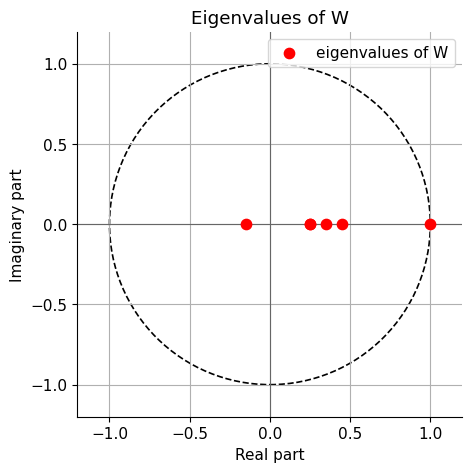

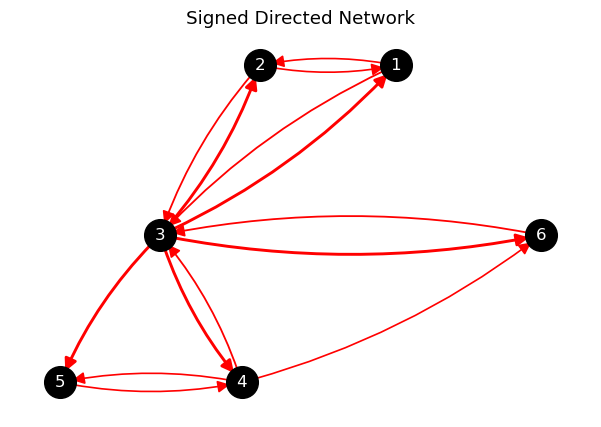

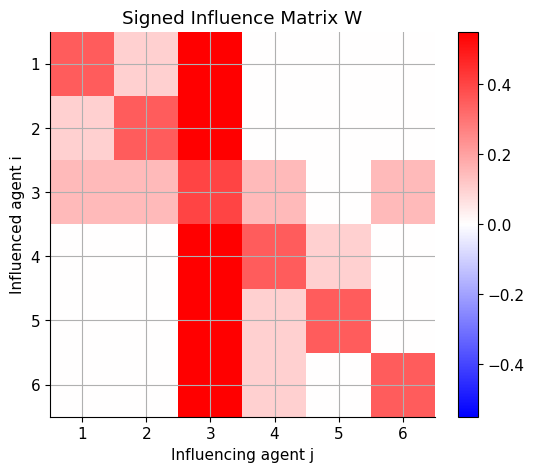

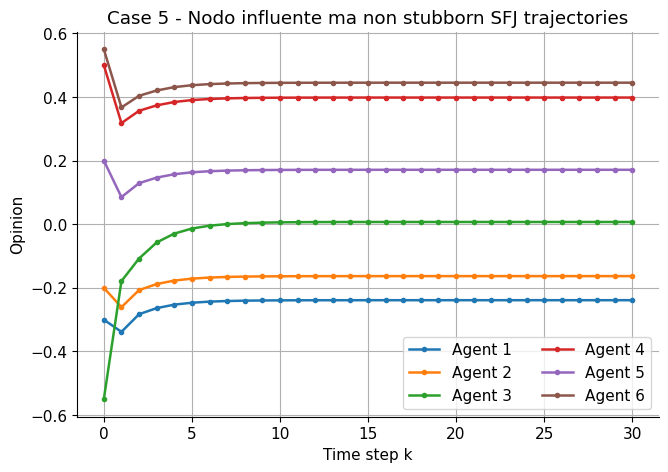

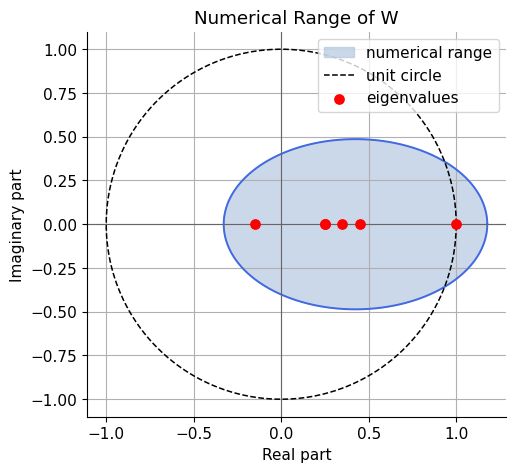

In [27]:

# Case 5 - Nodo influente ma non stubborn
a13 = 0.55
a23 = 0.55
a43 = 0.55
a53 = 0.55
a63 = 0.55

# secondary weak positive links
a12 = 0.10
a21 = 0.10
a45 = 0.10
a54 = 0.10
a64 = 0.10

# node 3 is influenced by others, but not too strongly
a31 = 0.15
a32 = 0.15
a34 = 0.15
a36 = 0.15

edges = [
    # node 3 as strong influencer
    (1, 3, a13),
    (2, 3, a23),
    (4, 3, a43),
    (5, 3, a53),
    (6, 3, a63),

    # secondary local links
    (1, 2, a12),
    (2, 1, a21),
    (4, 5, a45),
    (5, 4, a54),
    (6, 4, a64),

    # influences received by node 3
    (3, 1, a31),
    (3, 2, a32),
    (3, 4, a34),
    (3, 6, a36),
]

# node 3 is influential but not stubborn
theta = np.array([0.70, 0.70, 0.10, 0.70, 0.70, 0.70])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[5] = {
    "name": "Case 5 - Nodo influente ma non stubborn",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 5 - Nodo influente ma non stubborn SFJ trajectories")
plot_numerical_range(W)


## Case 6 - Nodo ponte tra due cluster

This case is run with the SFJ functions defined above.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.    +0.j  0.9231+0.j -0.188 +0.j  0.0304+0.j -0.1   +0.j -0.0455+0.j]
rho(W) = 1.000000
eig((I-Theta)W): [ 0.63  +0.j  0.5836+0.j -0.1195+0.j  0.0193+0.j -0.0624+0.j -0.0289+0.j]
rho((I-Theta)W) = 0.629994
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [1.    +0.j 0.8826+0.j 0.2989+0.j 0.3541+0.j 0.3436+0.j 0.3961+0.j]
rho(P_W) = 1.000000

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[0.3  0.4  0.3  0.   0.   0.  ]
 [0.4  0.3  0.3  0.   0.   0.  ]
 [0.3  0.3  0.2  0.2  0.   0.  ]
 [0.   0.   0.08 0.22 0.4  0.3 ]
 [0.   0.   0.   0.4  0.3  0.3 ]
 [0.   0.   0.   0.3  0.4  0.3 ]]

Stubbornness vector theta:
[0.35 0.4  0.3  0.4  0.35 0.4 ]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-0.2643 -0.2292 -0.2472  0.4004  0.32

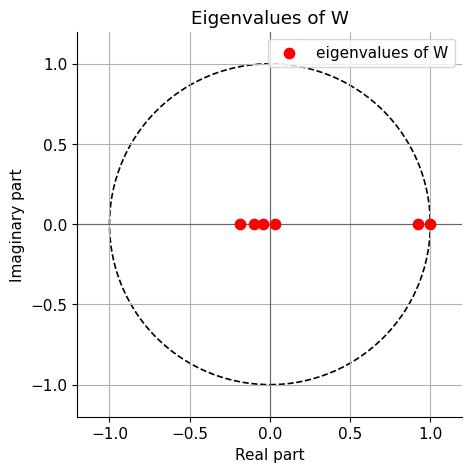

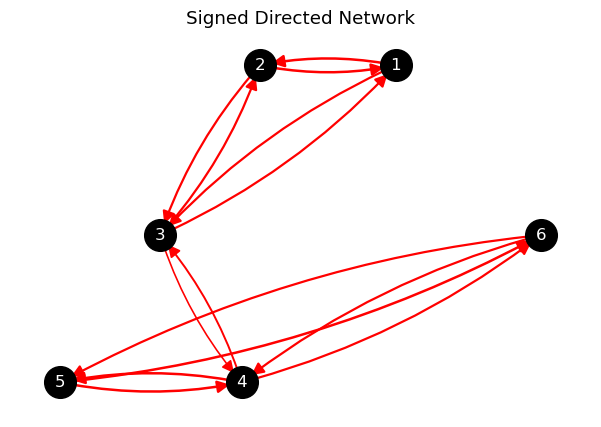

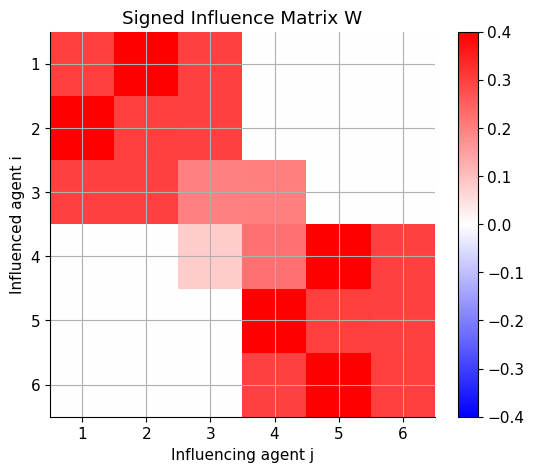

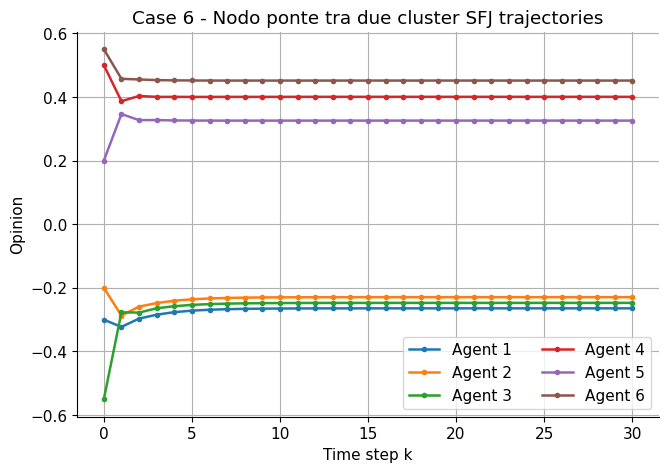

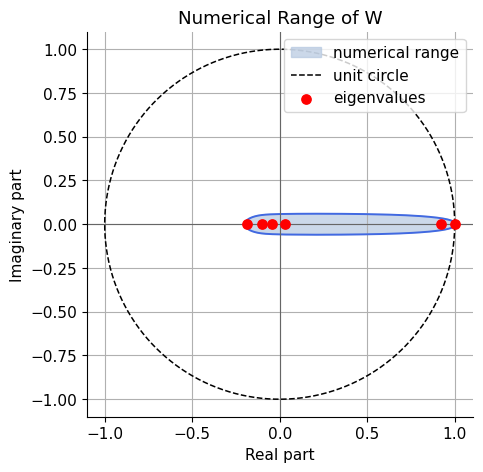

In [28]:

# Case 6 - Nodo ponte tra due cluster
a12 = 0.40
a13 = 0.30
a21 = 0.40
a23 = 0.30
a31 = 0.30
a32 = 0.30

a45 = 0.40
a46 = 0.30
a54 = 0.40
a56 = 0.30
a64 = 0.30
a65 = 0.40

# bridge from node 3 to node 4
a34 = 0.20
a43 = 0.08

edges = [
    # cluster 1
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),

    # bridge
    (3, 4, a34),
    (4, 3, a43),

    # cluster 2
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),
]

theta = np.array([0.35, 0.40, 0.30, 0.40, 0.35, 0.40])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[6] = {
    "name": "Case 6 - Nodo ponte tra due cluster",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 6 - Nodo ponte tra due cluster SFJ trajectories")
plot_numerical_range(W)


## Case 7 - Antagonismo asimmetrico

This case is run with the SFJ functions defined above.


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [ 1.25  +0.j  1.    +0.j -0.2197+0.j  0.1925+0.j  0.0842+0.j -0.007 +0.j]
rho(W) = 1.250000
eig((I-Theta)W): [ 0.776 +0.j  0.6299+0.j -0.1365+0.j  0.1198+0.j  0.0527+0.j -0.0044+0.j]
rho((I-Theta)W) = 0.775961
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [1.6899+0.j 1.    +0.j 0.4379+0.j 0.3296+0.j 0.3928+0.j 0.3628+0.j]
rho(P_W) = 1.689863

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[ 0.3   0.45  0.3  -0.05  0.    0.  ]
 [ 0.45  0.25  0.35  0.   -0.05  0.  ]
 [ 0.3   0.35  0.4   0.    0.   -0.05]
 [-0.2   0.    0.    0.45  0.4   0.35]
 [ 0.   -0.2   0.    0.4   0.45  0.35]
 [ 0.    0.   -0.2   0.35  0.4   0.45]]

Stubbornness vector theta:
[0.35 0.4  0.35 0.4  0.35 0.4 ]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-

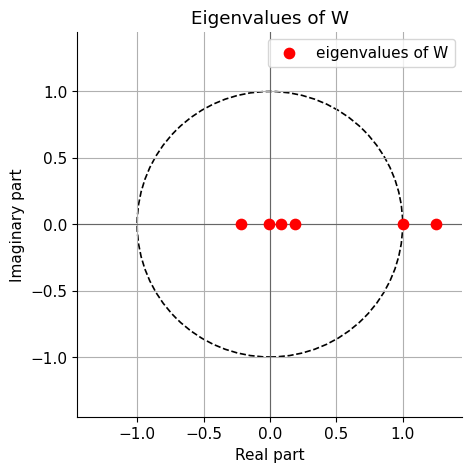

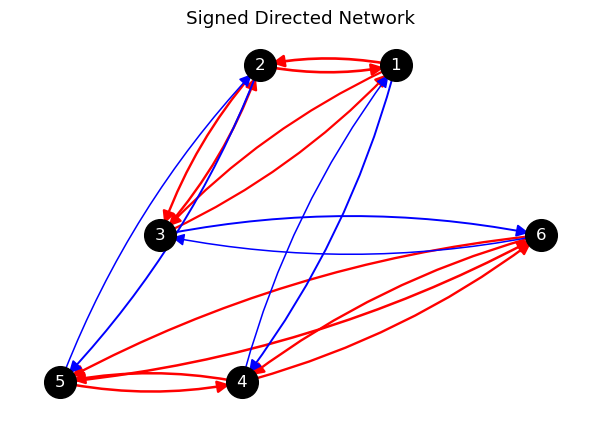

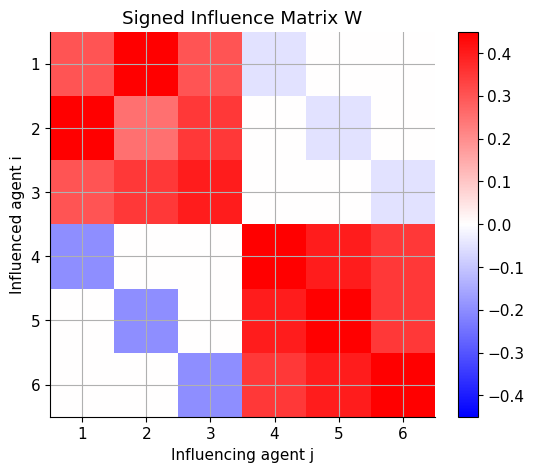

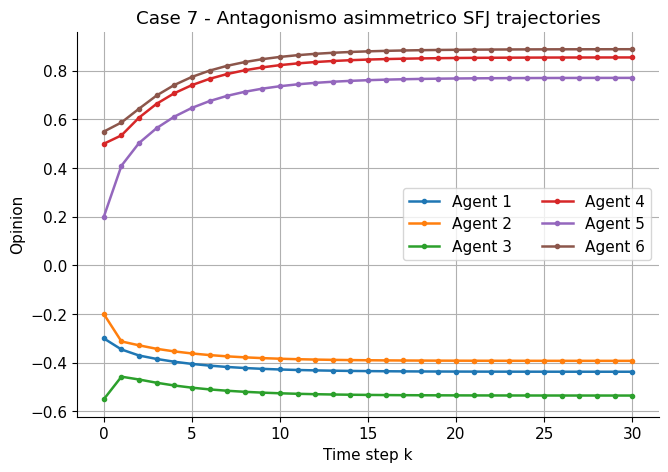

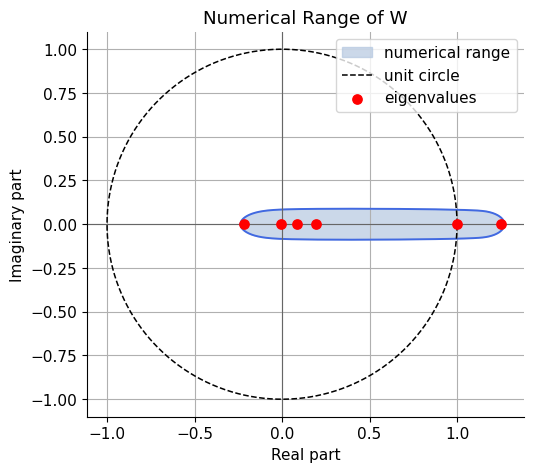

In [29]:

# Case 7 - Antagonismo asimmetrico
a12 = 0.45
a13 = 0.30
a21 = 0.45
a23 = 0.35
a31 = 0.30
a32 = 0.35

a45 = 0.40
a46 = 0.35
a54 = 0.40
a56 = 0.35
a64 = 0.35
a65 = 0.40

# group 1 strongly antagonizes group 2
a41 = -0.20
a52 = -0.20
a63 = -0.20

# group 2 weakly antagonizes group 1
a14 = -0.05
a25 = -0.05
a36 = -0.05

edges = [
    # positive cluster 1
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),

    # positive cluster 2
    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),

    # asymmetric negative cross-influence
    (4, 1, a41),
    (5, 2, a52),
    (6, 3, a63),

    (1, 4, a14),
    (2, 5, a25),
    (3, 6, a36),
]

theta = np.array([0.35, 0.40, 0.35, 0.40, 0.35, 0.40])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[7] = {
    "name": "Case 7 - Antagonismo asimmetrico",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 7 - Antagonismo asimmetrico SFJ trajectories")
plot_numerical_range(W)


## Case 8 - Rete quasi instabile

bassissima stubborness, dinamica lenta


Basic checks
------------
row sums of W: [1. 1. 1. 1. 1. 1.]
W @ 1 = 1: True

Spectrum
--------
eig(W): [1.2638+0.j 1.    +0.j 0.05  +0.j 0.1654+0.j 0.4289+0.j 0.3419+0.j]
rho(W) = 1.263800
eig((I-Theta)W): [0.9252+0.j 0.7088+0.j 0.0337+0.j 0.1205+0.j 0.3107+0.j 0.2301+0.j]
rho((I-Theta)W) = 0.925180
stable by the numerical test rho((I-Theta)W) < 1: True

P_W exists numerically: True
eig(P_W): [3.4925+0.j 1.    +0.j 0.2997+0.j 0.3304+0.j 0.4302+0.j 0.377 +0.j]
rho(P_W) = 3.492468

ES, EEP, sharp point, and strict dominance: not formally verified in this notebook, next step.
Signed influence matrix W:
[[ 0.4   0.35  0.25  0.    0.    0.  ]
 [ 0.35  0.4   0.25  0.    0.    0.  ]
 [ 0.25  0.25  0.8  -0.18  0.   -0.12]
 [ 0.    0.   -0.18  0.63  0.3   0.25]
 [ 0.    0.    0.    0.3   0.45  0.25]
 [ 0.    0.   -0.12  0.25  0.3   0.57]]

Stubbornness vector theta:
[0.3  0.35 0.2  0.3  0.25 0.35]

Initial opinion vector s:
[-0.3  -0.2  -0.55  0.5   0.2   0.55]

Equilibrium x* =
[-1.0162 -0.92

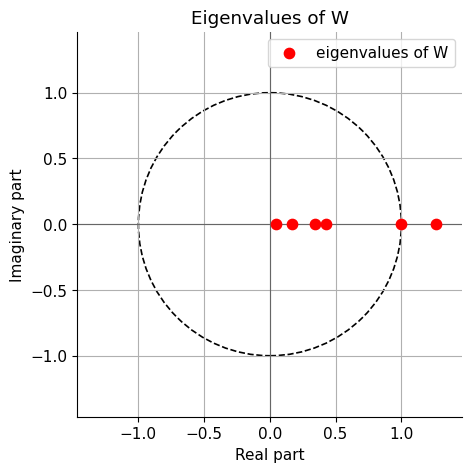

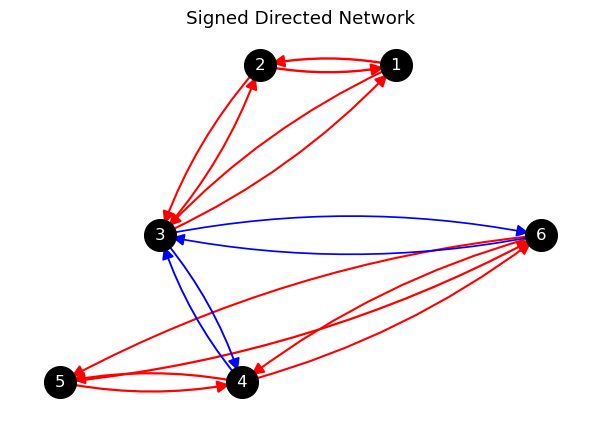

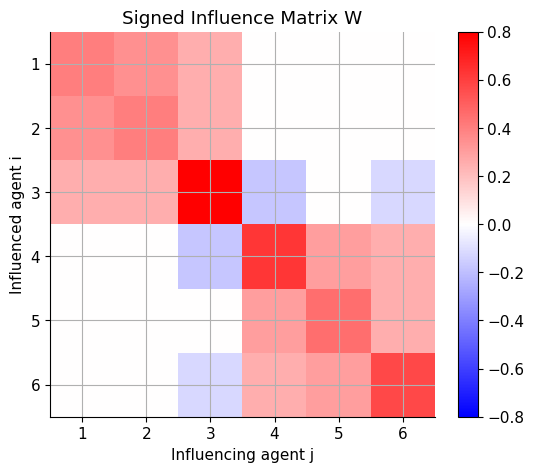

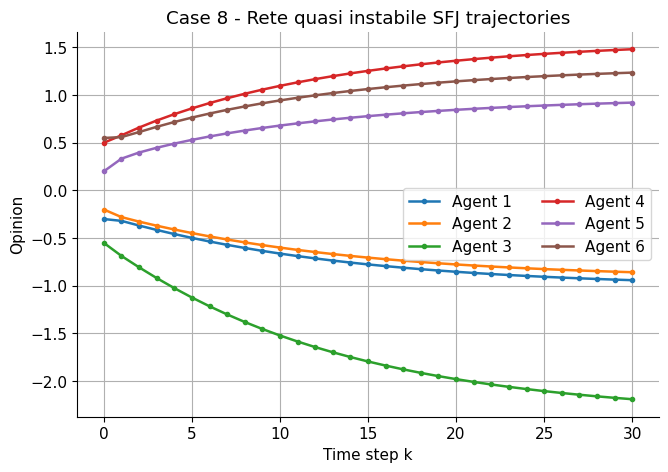

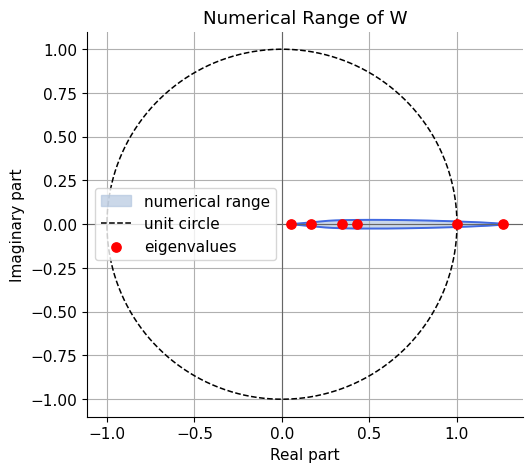

In [31]:

# Case 8 - Rete quasi instabile
a12 = 0.35
a13 = 0.25
a21 = 0.35
a23 = 0.25
a31 = 0.25
a32 = 0.25

a34 = -0.18
a43 = -0.18
a36 = -0.12
a63 = -0.12

a45 = 0.30
a46 = 0.25
a54 = 0.30
a56 = 0.25
a64 = 0.25
a65 = 0.30

edges = [
    (1, 2, a12),
    (1, 3, a13),
    (2, 1, a21),
    (2, 3, a23),
    (3, 1, a31),
    (3, 2, a32),

    (3, 4, a34),
    (4, 3, a43),
    (3, 6, a36),
    (6, 3, a63),

    (4, 5, a45),
    (4, 6, a46),
    (5, 4, a54),
    (5, 6, a56),
    (6, 4, a64),
    (6, 5, a65),
]

# very low stubbornness: stronger network effect
theta = np.array([0.3, 0.35, 0.2, 0.3, 0.25, 0.35])

W = build_W_from_edges(edges, n=6)

warn_about_assumptions(W, theta)
check_sfj_stability(W, theta)

# X stores trajectories with shape (n, T + 1), as in SFJModel.ipynb
X = simulate_sfj(W, theta, s, T)
P, x_star = compute_sfj_equilibrium(W, theta, s)

# The metric helper expects rows to be time steps, so transpose X here.
X_time = X.T
opinion_metrics_traj = compute_opinion_metrics_trajectory(X_time)
final_opinion_metrics = compute_opinion_metrics(X_time[-1])
stability_metrics = compute_stability_metrics(W, theta)

case_results[8] = {
    "name": "Case 8 - Rete quasi instabile",
    "W": W,
    "theta": theta,
    "X": X,
    "P": P,
    "x_star": x_star,
    "opinion_metrics_trajectory": opinion_metrics_traj,
    "final_opinion_metrics": final_opinion_metrics,
    "stability_metrics": stability_metrics,
}

print("Signed influence matrix W:")
print(W)

print("\nStubbornness vector theta:")
print(theta)

print("\nInitial opinion vector s:")
print(s)

print("\nEquilibrium x* =")
print(x_star)

print("\nFinal opinion metrics:")
for key, value in final_opinion_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nStability metrics:")
for key, value in stability_metrics.items():
    print(f"{key}: {value:.4f}" if np.isfinite(value) else f"{key}: inf")

plot_eigenvalues(W)
plot_signed_network(W, xpos, ypos)
plot_heatmap_W(W)
plot_opinion_trajectories(X, title="Case 8 - Rete quasi instabile SFJ trajectories")
plot_numerical_range(W)


## Cross-Case Summary

This table compares the final mean opinion, final polarization, final extremism, spectral radius, stability margin, convergence-time proxy, and negative-edge fraction across the eight toy cases.


In [32]:

summary_rows = []
for case_id, result in case_results.items():
    final = result["final_opinion_metrics"]
    stability = result["stability_metrics"]
    summary_rows.append([
        case_id,
        result["name"],
        final["mean_opinion"],
        final["polarization_variance"],
        final["mean_extremism"],
        stability["spectral_radius"],
        stability["stability_margin"],
        stability["convergence_time_proxy"],
        stability["negative_edge_fraction"],
    ])

try:
    import pandas as pd
    summary = pd.DataFrame(
        summary_rows,
        columns=[
            "case",
            "name",
            "final_mean_opinion",
            "final_polarization_variance",
            "final_mean_extremism",
            "spectral_radius",
            "stability_margin",
            "convergence_time_proxy",
            "negative_edge_fraction",
        ],
    )
    display(summary)
except ImportError:
    for row in summary_rows:
        print(row)


,case,name,final_mean_opinion,final_polarization_variance,final_mean_extremism,spectral_radius,stability_margin,convergence_time_proxy,negative_edge_fraction
0,1,Case 1 - Rete positiva cooperativa,0.052701,0.123077,0.347707,0.627074,0.372926,2.681496,0.000000
1,2,Case 2 - Due cluster positivi debolmente connessi,0.052107,0.136267,0.366343,0.627063,0.372937,2.681415,0.000000
2,3,Case 3 - Rete signed con antagonismo tra due g...,0.030427,0.411500,0.638607,0.775759,0.224241,4.459484,0.250000
3,4,Case 4 - Nodo altamente stubborn,0.056076,0.137498,0.356082,0.312875,0.687125,1.455339,0.000000
4,5,Case 5 - Nodo influente ma non stubborn,0.103193,0.067568,0.237167,0.566493,0.433507,2.306765,0.000000
5,6,Case 6 - Nodo ponte tra due cluster,0.072810,0.103656,0.319715,0.629994,0.370006,2.702659,0.000000
6,7,Case 7 - Antagonismo asimmetrico,0.191645,0.420819,0.646390,0.775961,0.224039,4.463503,0.250000
7,8,Case 8 - Rete quasi instabile,-0.058612,1.826983,1.270917,0.925180,0.074820,13.365422,0.181818
